# Global Power Plants: Energy Transition Analytics

**Business/research question:** how far along is the world's shift away from fossil fuel electricity, where is it happening fastest, and how reliable is the public data behind that question in the first place?

Dataset: the World Resources Institute Global Power Plant Database, roughly 28,700 power plants across 164 countries, representing about 80% of the world's generation capacity.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from portfolio import PALETTE, apply_house_style
from portfolio.paths import project_dir

apply_house_style()
pd.set_option("display.max_columns", None)

PROJECT = project_dir("06-energy-power-plants")
RAW = PROJECT / "data/raw/global_power_plant.csv"
PROCESSED = PROJECT / "data/processed/power_plants_clean.csv"
FIG = PROJECT / "outputs/figures"

## 1. Load and inspect

In [2]:
df = pd.read_csv(RAW)
print(f"{len(df):,} rows, {df.shape[1]} columns, {df['country'].nunique()} countries")
df.head(3)

28,664 rows, 22 columns, 164 countries


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,fuel1,fuel2,fuel3,fuel4,commissioning_year,owner,source,url,geolocation_source,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN


In [3]:
# Missingness is the first thing to understand on any real dataset
(df.isna().mean() * 100).round(1).sort_values(ascending=False).to_frame("pct_missing")

,pct_missing
fuel4,99.6
fuel3,99.0
generation_gwh_2013,98.5
generation_gwh_2014,98.4
generation_gwh_2015,96.7
fuel2,94.1
generation_gwh_2016,71.0
commissioning_year,47.8
year_of_capacity_data,43.7
owner,36.9


## 2. Data cleaning

Every step below is a judgement call, documented rather than applied silently:

- **Corrupted coordinates.** 17 rows (all in China) have a latitude or longitude outside the physically valid range. Several look like a dropped decimal point (e.g. `1075744` instead of `107.5744`). Rather than guess the fix, the coordinate pair is set to null for these rows — they drop out of the map, but every other column (capacity, fuel, age) is still used.
- **No imputation.** Missing `commissioning_year`, `owner`, and secondary fuel columns are left as null and excluded pairwise, not filled in. Fabricating a construction date would corrupt the age analysis, not fix it.
- **`estimated_generation_gwh` is used as the generation metric**, not the year-by-year `generation_gwh_2013–2016` columns, because those are 71–98.5% missing while the estimated figure (WRI's own modelled fill) is only 3.9% missing.
- **A `fuel_category` column is derived** from `fuel1`: Renewable (Hydro, Solar, Wind, Geothermal, Wave and Tidal), Fossil (Coal, Gas, Oil, Petcoke, Cogeneration), Nuclear, and Other (Biomass, Waste, Storage). Biomass and Waste are kept out of "Renewable" on purpose — their real-world emissions depend heavily on feedstock and combustion technology, so grouping them with Hydro/Solar/Wind would overstate the clean-capacity figure.

In [4]:
bad_coords = (df["latitude"].abs() > 90) | (df["longitude"].abs() > 180)
print(f"Invalid coordinates: {bad_coords.sum()} rows, all China:", df.loc[bad_coords, "country"].unique())
df.loc[bad_coords, ["latitude", "longitude"]] = np.nan

RENEWABLE_FUELS = {"Hydro", "Solar", "Wind", "Geothermal", "Wave and Tidal"}
FOSSIL_FUELS = {"Coal", "Gas", "Oil", "Petcoke", "Cogeneration"}

def classify_fuel(fuel: str) -> str:
    if fuel in RENEWABLE_FUELS:
        return "Renewable"
    if fuel in FOSSIL_FUELS:
        return "Fossil"
    if fuel == "Nuclear":
        return "Nuclear"
    return "Other"

df["fuel_category"] = df["fuel1"].map(classify_fuel)

REFERENCE_YEAR = 2018  # matches the dataset's own vintage
df["plant_age_years"] = REFERENCE_YEAR - df["commissioning_year"]

df.to_csv(PROCESSED, index=False)
print(f"Saved cleaned dataset: {len(df):,} rows")

Invalid coordinates: 17 rows, all China: <ArrowStringArray>
['CHN']
Length: 1, dtype: str
Saved cleaned dataset: 28,664 rows


## 3. Summary statistics

In [5]:
print(f"Total capacity: {df['capacity_mw'].sum():,.0f} MW across {len(df):,} plants in {df['country'].nunique()} countries\n")
summary = pd.DataFrame({
    "plants": df["fuel_category"].value_counts(),
    "capacity_mw": df.groupby("fuel_category")["capacity_mw"].sum().round(0),
})
summary["capacity_share_pct"] = (100 * summary["capacity_mw"] / summary["capacity_mw"].sum()).round(1)
summary["plant_share_pct"] = (100 * summary["plants"] / summary["plants"].sum()).round(1)
summary.sort_values("capacity_mw", ascending=False)

Total capacity: 5,334,302 MW across 28,664 plants in 164 countries



,plants,capacity_mw,capacity_share_pct,plant_share_pct
fuel_category,,,,
Fossil,8216,3522699.0,66.0,28.7
Renewable,17738,1349416.0,25.3,61.9
Nuclear,199,408613.0,7.7,0.7
Other,2511,53574.0,1.0,8.8


**First finding, before any research question:** renewables are already 62% of all *plants* but only 25% of *capacity*. Most new power plants being built today are renewable, but they are small and distributed (an average solar site is a fraction of the size of an average coal or nuclear plant), so the capacity mix hasn't caught up with the plant-count mix yet.

## 4. World map

Every plant, sized by capacity and coloured by fuel category. An interactive version is saved to `outputs/figures/00_world_map_interactive.html`.

In [6]:
map_df = df.dropna(subset=["latitude", "longitude"])
color_map = {"Renewable": PALETTE[2], "Fossil": PALETTE[1], "Nuclear": PALETTE[3], "Other": PALETTE[5]}

fig_map = go.Figure()
for cat, color in color_map.items():
    sub = map_df[map_df["fuel_category"] == cat]
    fig_map.add_trace(go.Scattergeo(
        lon=sub["longitude"], lat=sub["latitude"], mode="markers",
        marker=dict(size=np.clip(sub["capacity_mw"] ** 0.35, 2, 22), color=color, opacity=0.55, line=dict(width=0)),
        name=cat,
        text=sub["name"] + " (" + sub["country_long"] + ", " + sub["capacity_mw"].round(0).astype(str) + " MW)",
        hoverinfo="text",
    ))
fig_map.update_layout(
    title=f"{len(map_df):,} power plants worldwide, sized by capacity, coloured by fuel category",
    geo=dict(projection_type="natural earth", showland=True, landcolor="rgb(235,235,235)", showcountries=True),
    legend=dict(orientation="h", y=-0.05), margin=dict(l=0, r=0, t=40, b=0), height=550,
)
fig_map.write_html(str(FIG / "00_world_map_interactive.html"))
fig_map.show()

## Research question 1: which countries are furthest along the renewable transition?

**Why this question matters:** a country's generation mix determines its exposure to fossil fuel price shocks, its ability to meet climate commitments, and how it should plan grid investment. Looking at capacity share by country, restricted to grids of 5GW+ so the ranking isn't dominated by a single small country with one hydro dam, is the standard first cut for this in energy policy analysis.

**Limitation:** this dataset's vintage is roughly 2017–2018. Several Gulf states shown here with 0% renewable share have since announced or built significant solar capacity; this reflects the transition's starting point in this dataset, not necessarily today.

In [7]:
country_cap = df.groupby(["country_long", "fuel_category"])["capacity_mw"].sum().unstack(fill_value=0)
country_cap["total_mw"] = country_cap.sum(axis=1)
country_cap["renewable_share_pct"] = 100 * country_cap.get("Renewable", 0) / country_cap["total_mw"]
big_grids = country_cap[country_cap["total_mw"] >= 5000].sort_values("renewable_share_pct", ascending=False)
print(f"{len(big_grids)} countries with 5GW+ total capacity\n")
print("Leaders:"); print(big_grids[["total_mw", "renewable_share_pct"]].head(8).round(1))
print("\nLaggards:"); print(big_grids[["total_mw", "renewable_share_pct"]].tail(7).round(1))

73 countries with 5GW+ total capacity

Leaders:
fuel_category  total_mw  renewable_share_pct
country_long                                
Paraguay         8760.0                100.0
Norway          32551.0                 95.5
Tajikistan       5296.4                 88.5
New Zealand      6674.6                 82.6
Austria         11227.1                 81.6
Brazil         145788.5                 74.3
Switzerland     13097.8                 73.8
Colombia        10139.0                 66.0

Laggards:
fuel_category  total_mw  renewable_share_pct
country_long                                
Kuwait          17819.5                  0.0
Bahrain          7581.3                  0.0
Hungary          6083.7                  0.0
Belarus          8302.0                  0.0
Qatar           10548.0                  0.0
Libya            6231.0                  0.0
Singapore       13660.0                  0.0


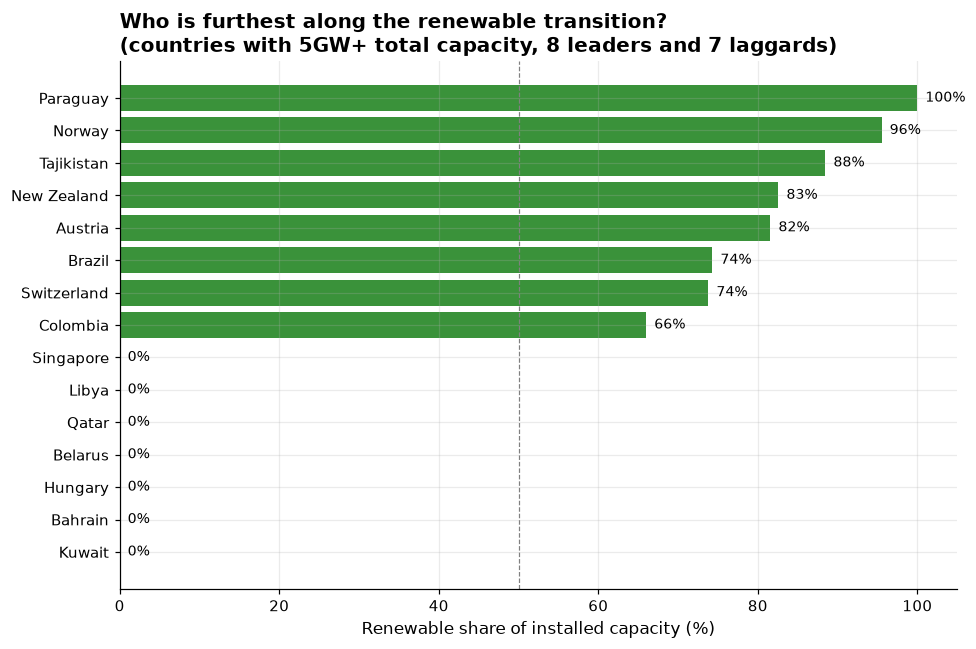

In [8]:
top15 = pd.concat([big_grids.head(8), big_grids.tail(7)]).sort_values("renewable_share_pct")
fig, ax = plt.subplots(figsize=(9, 6))
colors = [PALETTE[2] if v >= 50 else PALETTE[3] for v in top15["renewable_share_pct"]]
ax.barh(top15.index, top15["renewable_share_pct"], color=colors)
ax.set_xlabel("Renewable share of installed capacity (%)")
ax.set_title("Who is furthest along the renewable transition?\n(countries with 5GW+ total capacity, 8 leaders and 7 laggards)")
ax.axvline(50, color="grey", linewidth=0.8, linestyle="--")
for y, v in enumerate(top15["renewable_share_pct"]):
    ax.text(v + 1, y, f"{v:.0f}%", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "01_renewable_share_by_country.png")
plt.show()

**Finding:** hydro-rich countries dominate the top of the table (Paraguay 100%, Norway 96%, Tajikistan 88%), which is really a story about geography as much as policy. The bottom is almost entirely Gulf oil and gas states at or near 0%. Both ends of the table are explained by natural resource endowment more than by climate ambition alone.

## Research question 2: what does the age profile of the fleet say about the pace of replacement needed?

**Why this question matters:** power plants run for decades. A country's current fleet age tells you how much of it is approaching retirement, and therefore how large a replacement or retrofit programme is needed to hit a climate target — this is the "stranded asset" question that utilities and regulators actually plan around.

In [9]:
age_df = df.dropna(subset=["plant_age_years"])
age_df = age_df[age_df["plant_age_years"].between(0, 130)]
print(f"{len(age_df):,} plants with a known commissioning year ({len(age_df)/len(df)*100:.0f}% of the dataset)\n")
age_df.groupby("fuel_category")["plant_age_years"].describe()[["count", "mean", "50%", "75%"]].round(1)

14,952 plants with a known commissioning year (52% of the dataset)



,count,mean,50%,75%
fuel_category,,,,
Fossil,5751.0,23.0,18.0,33.0
Nuclear,99.0,34.5,34.0,42.0
Other,1276.0,16.8,12.0,24.1
Renewable,7826.0,24.5,10.0,36.0


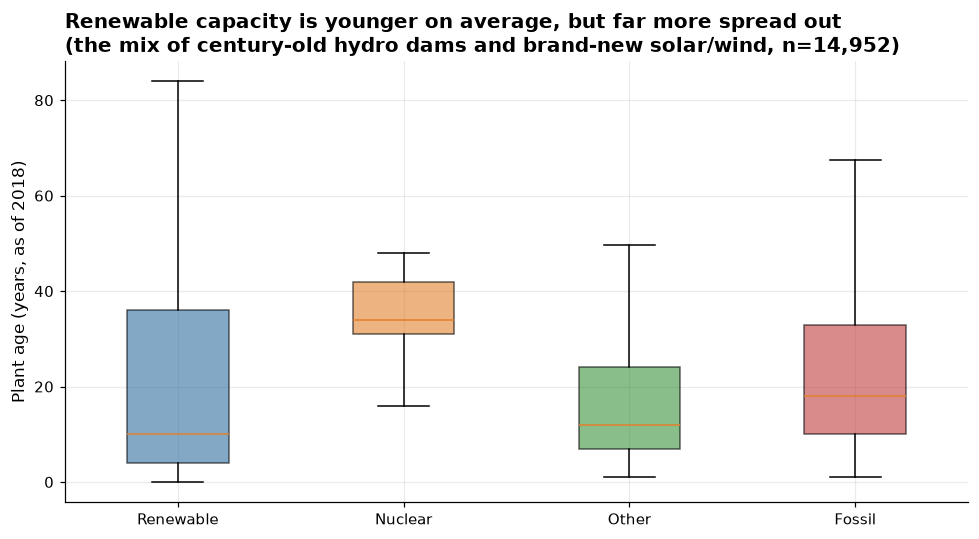

In [10]:
order = ["Renewable", "Nuclear", "Other", "Fossil"]
data = [age_df.loc[age_df.fuel_category == c, "plant_age_years"] for c in order]
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data, tick_labels=order, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_ylabel("Plant age (years, as of 2018)")
ax.set_title(f"Renewable capacity is younger on average, but far more spread out\n(the mix of century-old hydro dams and brand-new solar/wind, n={len(age_df):,})")
fig.tight_layout()
fig.savefig(FIG / "02_plant_age_by_fuel_category.png")
plt.show()

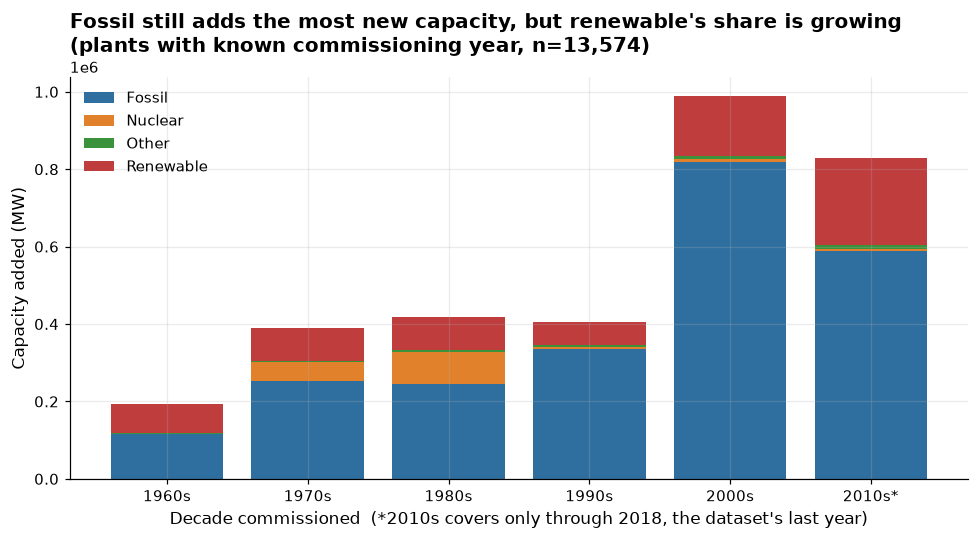

In [11]:
decade_df = age_df.copy()
decade_df["decade"] = (decade_df["commissioning_year"] // 10 * 10).astype(int)
decade_df = decade_df[decade_df["decade"] >= 1960]
decade_cap = decade_df.groupby(["decade", "fuel_category"])["capacity_mw"].sum().unstack(fill_value=0)
decade_cap = decade_cap.reindex(columns=["Fossil", "Nuclear", "Other", "Renewable"], fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
x = decade_cap.index.values
bottom = np.zeros(len(decade_cap))
for i, col in enumerate(decade_cap.columns):
    ax.bar(x, decade_cap[col].values, bottom=bottom, label=col, color=PALETTE[i], width=8)
    bottom += decade_cap[col].values
ax.set_xticks(x)
labels = [f"{d}s" for d in x]; labels[-1] += "*"
ax.set_xticklabels(labels)
ax.set_xlabel("Decade commissioned  (*2010s covers only through 2018, the dataset's last year)")
ax.set_ylabel("Capacity added (MW)")
ax.set_title(f"Fossil still adds the most new capacity, but renewable's share is growing\n(plants with known commissioning year, n={len(decade_df):,})")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "03_capacity_added_by_decade.png")
plt.show()

**Finding:** the renewable fleet's median age (10 years) is much younger than fossil's (18 years), but its spread is huge — the box runs from about 4 to 36 years, because "Renewable" mixes brand-new solar farms with hydro dams built decades ago. Looking at capacity added per decade, fossil fuel has added more new capacity than renewables in every decade since the 1950s, including the 2010s, but renewable's share of new capacity has grown from 15% in the 2000s to 27% in the 2010s (partial decade). The transition is real and accelerating, but fossil fuel is still winning the race for new capacity, not losing it.

## Research question 3: how reliable is public reporting on power plants, and does it vary by fuel type?

**Why this question matters:** almost half the dataset has no commissioning year at all. If that gap isn't random, it changes how much you can trust any age- or vintage-based conclusion, including research question 2 above — and it's a legitimate finding in its own right about which parts of the energy system are least transparent.

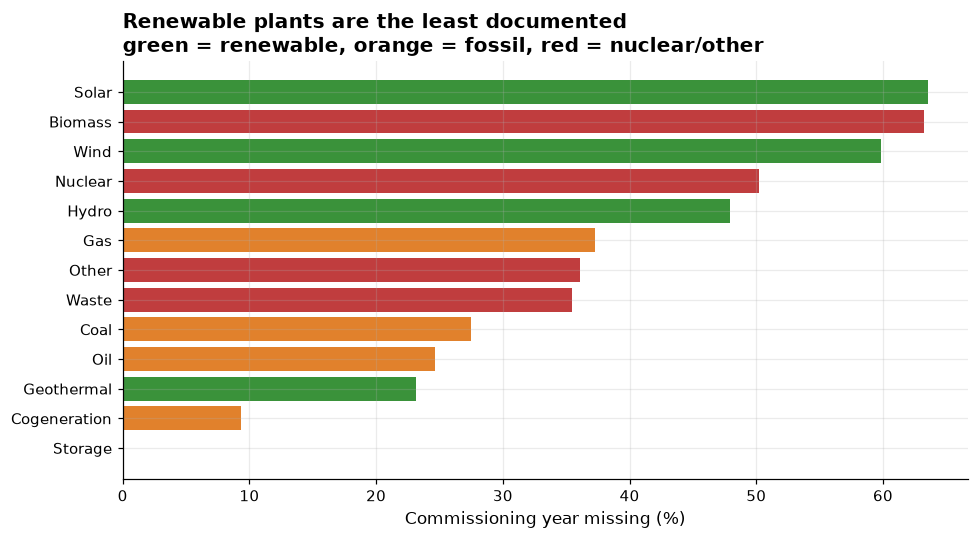

In [12]:
report_gap = df.groupby("fuel1")["commissioning_year"].apply(lambda s: s.isna().mean() * 100).sort_values(ascending=False)
report_gap = report_gap[df["fuel1"].value_counts()[report_gap.index] >= 30]

colors = [PALETTE[2] if f in RENEWABLE_FUELS else (PALETTE[1] if f in FOSSIL_FUELS else PALETTE[3]) for f in report_gap.index]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(report_gap.index[::-1], report_gap.values[::-1], color=colors[::-1])
ax.set_xlabel("Commissioning year missing (%)")
ax.set_title("Renewable plants are the least documented\ngreen = renewable, orange = fossil, red = nuclear/other")
fig.tight_layout()
fig.savefig(FIG / "04_reporting_gap_by_fuel.png")
plt.show()

**Finding:** solar, biomass, and wind (all recent, often small, often privately developed) are missing a commissioning year for 60–64% of plants. Coal, oil, and cogeneration, the older and more heavily regulated utility-scale technologies, are best documented. This means research question 2's fossil-versus-renewable age comparison is itself biased towards the *better-documented* half of each fleet — worth stating plainly rather than glossing over.

## Summary

See [`report.md`](../report.md) for the full written analysis, and [`README.md`](../README.md) for the one-page version.